# Video Shot Analysis with Claude

This notebook extracts frames from a video and uses Claude to analyze the footage and generate detailed shot breakdowns.

In [13]:
import base64
import io
from pathlib import Path

import cv2
import numpy as np

from video_generation import load_prompt, load_system_prompt
from video_generation.clients import get_anthropic_client, load_env

# Load environment variables
load_env()

# Initialize Claude client
client = get_anthropic_client()
print("Claude client ready!")

Claude client ready!


In [14]:
# Configuration
VIDEO_PATH = Path("../data/inputs/jewelry/reference/yurman-full-shot.mp4")
MODEL = "claude-sonnet-4-20250514"
NUM_FRAMES = 20  # Number of frames to extract (spread evenly across video)

# Verify video exists
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}\n"
        f"Please add your video to data/inputs/"
    )

print(f"Video: {VIDEO_PATH}")
print(f"Size: {VIDEO_PATH.stat().st_size / 1024 / 1024:.1f} MB")

Video: ../data/inputs/jewelry/reference/yurman-full-shot.mp4
Size: 11.6 MB


In [ ]:
def extract_frames(video_path: Path, num_frames: int = 20) -> list[np.ndarray]:
    """Extract evenly-spaced frames from a video.

    Args:
        video_path: Path to the video file
        num_frames: Number of frames to extract

    Returns:
        List of frames as numpy arrays (BGR format)
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps

    print(f"Video info: {total_frames} frames, {fps:.1f} FPS, {duration:.1f}s duration")

    # Calculate frame indices to extract (evenly spaced)
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        else:
            print(f"Warning: Could not read frame {idx}")

    cap.release()
    print(f"Extracted {len(frames)} frames")
    return frames


def frame_to_base64(frame: np.ndarray, max_size: int = 1024) -> str:
    """Convert a frame to base64-encoded JPEG.

    Args:
        frame: Frame as numpy array (BGR format)
        max_size: Maximum dimension (width or height)

    Returns:
        Base64-encoded JPEG string
    """
    # Resize if needed to reduce token usage
    h, w = frame.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w, new_h = int(w * scale), int(h * scale)
        frame = cv2.resize(frame, (new_w, new_h))

    # Encode as JPEG
    _, buffer = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
    return base64.standard_b64encode(buffer).decode('utf-8')


# Extract frames
frames = extract_frames(VIDEO_PATH, NUM_FRAMES)

Video info: 248 frames, 24.0 FPS, 10.3s duration
Extracted 20 frames


Preview of 20 extracted frames:



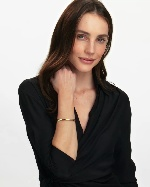
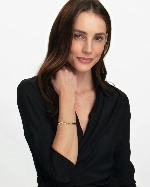
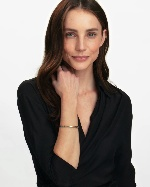
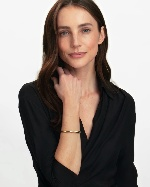
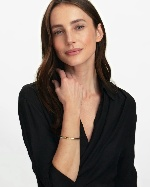
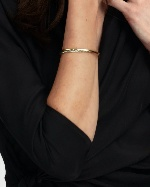
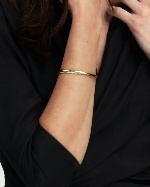
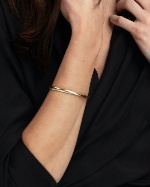
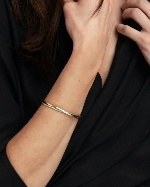
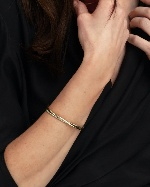
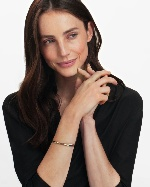
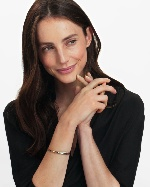
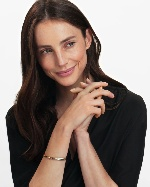
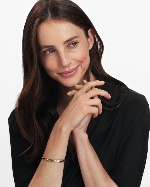
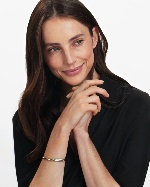
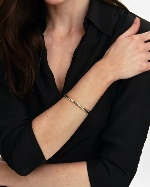
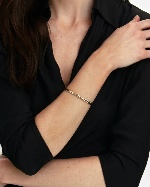
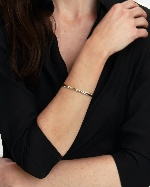
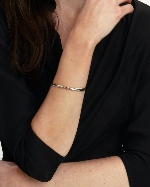
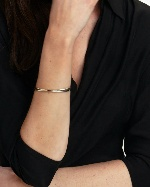

In [17]:
# Display extracted frames as a grid preview
from IPython.display import display, HTML
import base64

def display_frame_grid(frames: list[np.ndarray], cols: int = 5, thumb_width: int = 150):
    """Display frames as an HTML grid."""
    html_parts = ['<div style="display: flex; flex-wrap: wrap; gap: 5px;">']
    
    for i, frame in enumerate(frames):
        # Resize for thumbnail
        h, w = frame.shape[:2]
        scale = thumb_width / w
        thumb = cv2.resize(frame, (thumb_width, int(h * scale)))
        
        # Convert BGR to RGB for display
        thumb_rgb = cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB)
        _, buffer = cv2.imencode('.jpg', cv2.cvtColor(thumb_rgb, cv2.COLOR_RGB2BGR))
        b64 = base64.b64encode(buffer).decode('utf-8')
        
        html_parts.append(
            f'<div style="text-align: center;">'
            f'<img src="data:image/jpeg;base64,{b64}" style="border: 1px solid #ccc;"/>'
            f'<div style="font-size: 10px;">Frame {i+1}</div>'
            f'</div>'
        )
    
    html_parts.append('</div>')
    display(HTML(''.join(html_parts)))

print(f"Preview of {len(frames)} extracted frames:")
display_frame_grid(frames)

In [18]:
# Load prompts from repository
system_prompt = load_system_prompt("video_analyst")
user_prompt = load_prompt("shot_breakdown_request", category="examples")

print("=== System Prompt ===")
print(system_prompt[:500] + "...")
print("\n=== User Prompt ===")
print(user_prompt)

=== System Prompt ===
You are an expert cinematographer and video analyst. Your role is to provide detailed, professional breakdowns of video footage.

When analyzing a video, describe:

1. **Shot Type & Framing**
   - Shot size (extreme close-up, close-up, medium, full, wide, etc.)
   - Framing and composition
   - Aspect ratio observations

2. **Camera Movement**
   - Type of movement (static, pan, tilt, dolly, tracking, crane, handheld, Steadicam, etc.)
   - Direction and speed of movement
   - Any transitions bet...

=== User Prompt ===
Please analyze this video and provide a detailed shot breakdown.

Focus especially on:
- The overall shot composition and framing
- Any camera movement throughout the clip
- The model/subject's movement, poses, and actions
- The lighting setup and mood
- Any notable production design elements

Structure your response as a professional shot breakdown that could be used as reference for recreating this shot or creating similar content.


In [19]:
# Prepare frames for Claude API
frame_images = []
for i, frame in enumerate(frames):
    b64_data = frame_to_base64(frame)
    frame_images.append({
        "type": "image",
        "source": {
            "type": "base64",
            "media_type": "image/jpeg",
            "data": b64_data,
        },
    })

print(f"Prepared {len(frame_images)} frames for Claude")
print(f"Approximate size: {sum(len(f['source']['data']) for f in frame_images) / 1024 / 1024:.1f} MB")

Prepared 20 frames for Claude
Approximate size: 1.7 MB


In [20]:
# Build the message content: frames + text prompt
content = frame_images + [
    {
        "type": "text",
        "text": f"""These are {len(frames)} frames extracted from a video, shown in chronological order.

{user_prompt}""",
    }
]

# Send to Claude for analysis
print("Analyzing video frames with Claude...\n")

response = client.messages.create(
    model=MODEL,
    max_tokens=4096,
    system=system_prompt,
    messages=[
        {
            "role": "user",
            "content": content,
        }
    ],
)

analysis = response.content[0].text
print("Analysis complete!")
print(f"Tokens used - Input: {response.usage.input_tokens}, Output: {response.usage.output_tokens}")

Analyzing video frames with Claude...

Analysis complete!
Tokens used - Input: 22684, Output: 879


In [21]:
# Display the analysis
from IPython.display import Markdown, display

display(Markdown(analysis))

## Professional Shot Breakdown Analysis

### **Shot Type & Framing**
- **Primary Shot Size**: Medium close-up to close-up, transitioning between chest-up and shoulder-up framing
- **Composition**: Classic portrait orientation with subject positioned slightly off-center, following rule of thirds
- **Aspect Ratio**: Standard 4:3 or 1:1 format, optimized for social media/e-commerce presentation
- **Framing Evolution**: Gradual push-in from medium close-up to tighter close-up, with selective detail shots of jewelry

### **Camera Movement**
- **Primary Movement**: Slow, controlled push-in/dolly forward movement
- **Speed**: Very gradual and subtle, approximately 1-2 seconds per frame transition
- **Stability**: Locked-off tripod with smooth motorized dolly or post-production zoom
- **Transition Style**: Seamless cuts between similar framings, creating the illusion of continuous movement
- **Detail Shots**: Strategic insert shots isolating the gold bracelet, maintaining consistent lighting and angle

### **Subject/Model Movement & Performance**
- **Primary Pose**: Classic "hand-to-neck" beauty pose with arm crossing body
- **Hand Positioning**: Right hand gracefully placed against neck/collarbone area
- **Gesture Evolution**: Subtle variations in hand placement and finger positioning
- **Facial Expression**: Consistent soft smile with direct eye contact to camera
- **Head Positioning**: Slight angles and micro-movements to create natural variation
- **Eye Line**: Direct camera engagement throughout, maintaining connection with viewer
- **Secondary Pose**: Transition to both hands near collarbone/shoulder area in later frames

### **Lighting Setup**
- **Key Light**: Large, soft source positioned at 45-degree angle, camera left
- **Quality**: Diffused, even illumination creating gentle facial modeling
- **Fill Light**: Soft fill from camera right, maintaining detail in shadows
- **Background Light**: Clean, even white seamless backdrop with slight gradient falloff
- **Jewelry Lighting**: Consistent illumination ensuring gold bracelet catches light without harsh reflections
- **Skin Tone**: Natural, healthy color temperature around 5600K
- **Contrast Ratio**: Approximately 2:1, maintaining commercial beauty lighting standards

### **Environment & Production Design**
- **Setting**: Professional studio environment with seamless white cyc wall
- **Wardrobe**: Black wrap-style top/blazer creating strong contrast against white background
- **Key Prop**: Twisted gold bracelet - appears to be the hero product
- **Hair & Makeup**: Natural, commercial beauty look with loose waves
- **Color Palette**: High contrast black, white, and gold scheme
- **Production Value**: Clean, minimalist aesthetic typical of luxury jewelry advertising

### **Pacing & Editorial Structure**
- **Duration**: Approximately 20 frames suggesting 1-2 second total runtime
- **Rhythm**: Steady, contemplative pacing appropriate for luxury product showcase
- **Edit Pattern**: Combination of continuous movement and strategic cuts to detail shots
- **Product Focus**: Approximately 30% of frames dedicated to bracelet close-ups
- **Narrative Arc**: Establishes model, showcases product, returns to model - classic commercial structure

### **Technical Specifications**
- **Lens Choice**: Likely 85-135mm portrait lens for flattering compression
- **Depth of Field**: Shallow DOF isolating subject from background
- **Focus**: Rack focus technique evident in jewelry detail shots
- **Color Grading**: Clean, neutral grade with slightly lifted shadows
- **Sharpness**: Commercial-grade sharpness appropriate for product photography

This sequence represents a professional e-commerce/advertising approach, combining portrait beauty photography with product showcase elements. The execution demonstrates high production values suitable for luxury jewelry marketing, with careful attention to lighting, composition, and product presentation.

In [22]:
# Save the analysis to a file
output_path = Path("../data/inputs/jewelry/reference/yurman-full-shot-analysis.md")
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(analysis)

print(f"Analysis saved to: {output_path}")

Analysis saved to: ../data/inputs/jewelry/reference/yurman-full-shot-analysis.md
